___
<h1> Machine Learning </h1>
<h2> M. Sc. in Electrical and Computer Engineering </h2>
<h3> Instituto Superior de Engenharia / Universidade do Algarve </h3>

[MEEC](https://ise.ualg.pt/en/curso/1477) / [ISE](https://ise.ualg.pt) / [UAlg](https://www.ualg.pt)

Pedro J. S. Cardoso (pcardoso@ualg.pt)
___

# Adding Missing data
## Introduction

In this notebook we'll be looking of two issues:
- Missing data
- Converting categorical to numerical 

## Missing Data

- Missing values are common in dealing with real-world problems (data from long periods, multiple sources) 
- ML models require careful handling of missing data. 
- One strategy is imputing the missing values. Stategies include
    - interpolation, e.g., mean, median or mode
    - matrix factorization methods like SVD
    - statistical models like Kalman filters
    - etc

In this notebook we'll be looking at: 
- Mean -  average of all values in a set
- Median - the "middle" number in a set of numbers sorted by size
- Mode - the most common category / numerical value.

More, basic Pandas DataFrame operation will be used.

So, first, in kaggle you can find a competion which tries to build predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc). See https://www.kaggle.com/competitions/titanic/ for full details. 

Let us try to build our own participating solution and, for that, start by loading the dataset using the pandas library. 

In [1]:
import pandas as pd

titanic_df = pd.read_csv("data/titanic_train.csv")
titanic_df.head(5) # show the first 5 lines

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


We can see immediately that:
- there are categorical and numerical features
- there are some missing values

this can also be cheched by running the `.info()` method and looking to the _Non-Null Count_ column

In [2]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


For example, _Age_ is number (float64) and is define for 714 rows. 

As many algorithms do not accept `nan` values, several strategies can be taken to solve this, e.g.:
- remove rows with _nan_
- numerical data: replace the _nan_ values by, e.g., 0, mean, median etc.
- categorical data: replace the _nan_ values by, e.g., mode, "" (empty string) etc.

### Remove rows with _nan_

Removing rows with `nan`, can be achieve using `.dropna()` method, but can represent a major loss of the original data

In [3]:
# remove non uncomplete rows
titanic_df_with_nan_dropped = titanic_df.dropna()
titanic_df_with_nan_dropped.info()

<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 1 to 889
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  183 non-null    int64  
 1   Survived     183 non-null    int64  
 2   Pclass       183 non-null    int64  
 3   Name         183 non-null    object 
 4   Sex          183 non-null    object 
 5   Age          183 non-null    float64
 6   SibSp        183 non-null    int64  
 7   Parch        183 non-null    int64  
 8   Ticket       183 non-null    object 
 9   Fare         183 non-null    float64
 10  Cabin        183 non-null    object 
 11  Embarked     183 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 18.6+ KB


The original dataset had 891 entries which would be reduced to 183. Maybe this not a good idea...! 

### Numerical data: replace the nan values by, e.g., 0, mean, median etc.

In the example exists numerical (_Age_) and categorical(_Cabin_) missing data. Let us look first to the numerical one.

First look at the distribution of the data

<Axes: >

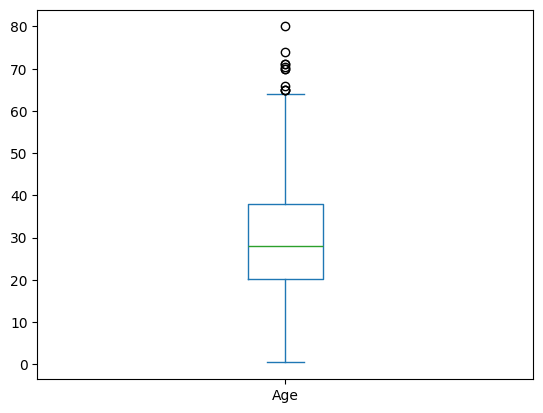

In [4]:
titanic_df["Age"].plot(kind="box")

<Axes: ylabel='Frequency'>

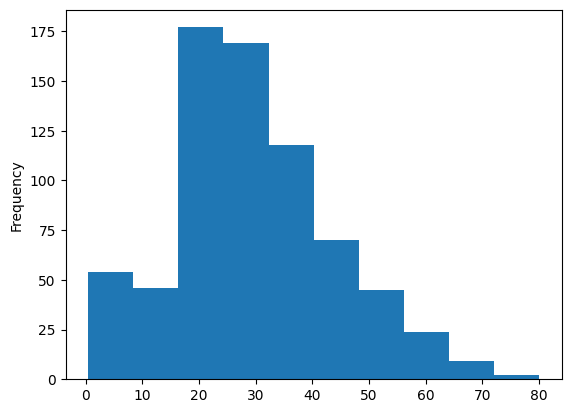

In [5]:
titanic_df["Age"].plot(kind="hist")

- Replace Missing Values with Mean
    - when data is "centered" - equaly distributed around the mean value

- Replace Missing Values with Median
    - when data is "skewed" - not equaly distributed around the mean value


First compute the `mean` / `median` (we could also define our own constant)

In [6]:
# remove non uncomplete rows
value_to_replace_nan = titanic_df["Age"].median() #try with 0, .median()
print("value_to_replace_nan: ", value_to_replace_nan)

value_to_replace_nan:  28.0


Then use the `.fillna()` method applied to the _Age_ column with the computed value

In [7]:
titanic_df_with_nan_replaced_by_mean = titanic_df.copy() # make a copy so we do not loose original dataset for later experiments!

titanic_df_with_nan_replaced_by_mean["Age"] = titanic_df["Age"].fillna(value_to_replace_nan)

You can check that the dataframe no longer misses values on the _Age_ column

In [8]:
titanic_df_with_nan_replaced_by_mean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Categorical data: replace the nan values by, e.g., mode, "" (empty string) etc.

This case is somehow distinct from other since, the _Cabin_ column has "lots" of distinct values, with "few" repetitions. 
In other cases this can be values from more limited sets (e.g, a color, True/False, animal species, etc).

In [9]:
print(set(titanic_df["Cabin"]))

{'B41', 'B78', 'B35', 'C126', 'E24', 'C86', 'C95', 'D47', 'E77', 'D33', 'C54', 'C49', 'A5', 'C103', 'D37', 'F G63', 'C128', 'B102', 'C110', 'A34', 'B73', 'C85', 'C23 C25 C27', 'D26', 'B42', 'B79', 'G6', 'D7', 'E40', 'E34', 'D49', 'C83', 'C7', 'D20', 'A26', 'B30', 'D50', 'B58 B60', 'C123', 'B19', 'C99', 'C82', 'D45', 'D56', 'B101', 'A20', 'D35', 'C125', 'A31', 'D46', 'B5', 'E67', 'A23', 'A14', 'E58', 'C47', 'B4', 'D6', 'A36', 'C118', 'D9', 'A10', 'B38', 'E68', 'A19', 'D', 'C45', 'B3', 'B82 B84', 'C92', 'E31', 'D36', 'E8', 'F33', 'C68', 'C104', 'C101', 'C32', 'B20', 'D28', 'C52', 'C65', 'E36', 'C62 C64', 'E10', 'B28', 'B39', 'F E69', 'E121', 'C30', 'A24', 'C90', 'B94', 'A32', 'T', 'B71', 'E44', 'C124', 'D30', 'C22 C26', 'B69', 'B18', 'D21', 'F38', 'B80', 'B51 B53 B55', 'C106', 'B57 B59 B63 B66', 'C111', 'B77', 'B96 B98', 'D15', 'E50', 'D17', 'E46', 'E101', nan, 'A6', 'C78', 'C46', 'C87', 'A16', 'E38', 'C148', 'D11', 'C93', 'E49', 'B37', 'C2', 'A7', 'C50', 'E33', 'F G73', 'B22', 'B49', 'C

So, maybe, it would be more useful to know the deck (1st letter) and from there compute the mode

In [10]:
def transf(x):
    try:
        return x[0] # return 1st letter
    except:
        return x # return the value if an exception was rased (e.g., when x is nan)

titanic_cabin_df = titanic_df.copy() # make a copy so we do not loose original dataset for later experiments!
titanic_cabin_df["Cabin"] = titanic_df["Cabin"].apply(transf)

titanic_cabin_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,C


We can now see that, for the known cabins/"deck", the mode should be "C" by plotting an histogram

<Axes: xlabel='Cabin'>

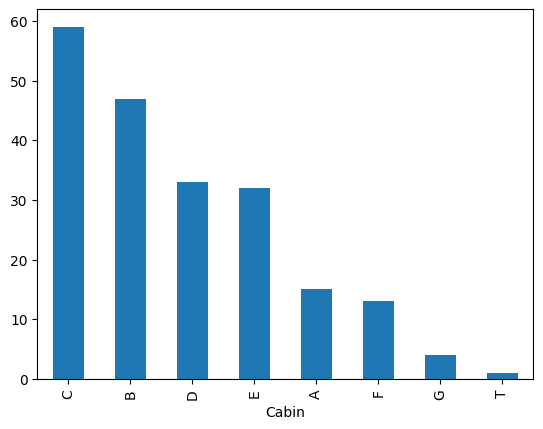

In [11]:
titanic_cabin_df["Cabin"].value_counts().plot(kind='bar')

Or by computing the mode of the "Cabin" column

In [12]:
value_to_replace_nan = titanic_cabin_df["Cabin"].mode()
value_to_replace_nan

0    C
Name: Cabin, dtype: object

As before we can use the `.fillna()` method

In [13]:
titanic_cabin_df["Cabin"] = titanic_cabin_df["Cabin"].fillna(value_to_replace_nan[0])
titanic_cabin_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,C,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,C,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,C,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,C,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,C,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,C


## Converting categorical to numerical

The majority of the ML algorithms does not accept categorical (string) values as input. So categorical data must be somehow converted to numerical.
Solutions include:
- categories mapping (e.g., True->1 / False->0 or S->0 / M->1 / L->2 / etc.)
- one hot encoding of data

Here we'll be looking at the later case (one hot encoding )

For a simpler example, consider the following pandas dataframe

In [14]:
df = pd.DataFrame({"Col1": ["a", "b","a", "a", "c"]})
df

,Col1
0,a
1,b
2,a
3,a
4,c


Now, pandas provides the `.get_dummies()` method, resulting in

In [15]:
pd.get_dummies(df)

,Col1_a,Col1_b,Col1_c
0,True,False,False
1,False,True,False
2,True,False,False
3,True,False,False
4,False,False,True


For the Titanic example we could just do, which whill apply the `.get_dummies()` method to all categorical columns.

In [16]:
pd.get_dummies(titanic_df)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,"Name_Abbing, Mr. Anthony","Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)",...,Cabin_F G73,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,5,0,3,35.0,0,0,8.0500,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000,False,False,False,...,False,False,False,False,False,False,False,False,False,True
887,888,1,1,19.0,0,0,30.0000,False,False,False,...,False,False,False,False,False,False,False,False,False,True
888,889,0,3,NaN,1,2,23.4500,False,False,False,...,False,False,False,False,False,False,False,False,False,True
889,890,1,1,26.0,0,0,30.0000,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In our case, the previous operation should be combined with the previous ones as 1371 columns where returned (for instance a column was creted for each name in the dataframe)

In [17]:
print(set(pd.get_dummies(titanic_df).columns))

{'Ticket_248706', 'Cabin_E10', 'Ticket_2683', 'Ticket_695', 'Name_Ford, Mr. William Neal', 'Ticket_WE/P 5735', 'Name_Slabenoff, Mr. Petco', 'Name_Rosblom, Mrs. Viktor (Helena Wilhelmina)', 'Ticket_315089', 'Name_Lundahl, Mr. Johan Svensson', 'Name_Chambers, Mrs. Norman Campbell (Bertha Griggs)', 'Name_Tornquist, Mr. William Henry', 'Ticket_335677', 'Cabin_B102', 'Cabin_E49', 'Name_Morley, Mr. Henry Samuel ("Mr Henry Marshall")', 'Name_Svensson, Mr. Olof', 'Name_Ahlin, Mrs. Johan (Johanna Persdotter Larsson)', 'Ticket_347067', 'Ticket_14973', 'Name_Carlsson, Mr. August Sigfrid', 'Name_Cumings, Mrs. John Bradley (Florence Briggs Thayer)', 'Name_Leader, Dr. Alice (Farnham)', 'Ticket_C.A. 37671', 'Name_Sloper, Mr. William Thompson', 'Ticket_SOTON/O.Q. 3101311', 'Name_Bowen, Mr. David John "Dai"', 'Ticket_347077', 'Ticket_STON/O2. 3101271', 'Cabin_A19', 'Cabin_E8', 'Ticket_65304', 'Name_Abbott, Mrs. Stanton (Rosa Hunt)', 'Name_Waelens, Mr. Achille', 'Name_Heininen, Miss. Wendla Maria', 'Tic